# Hotel Booking Cancellation — Exploratory Data Analysis

**Dataset:** [Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) (Antonio, Almeida & Nunes, 2019), sourced via Kaggle — 119,390 bookings across a City Hotel and a Resort Hotel in Portugal, spanning 2015–2017.

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`

### Project Objective
The objective of this exploratory data analysis is to examine hotel booking behavior and identify booking, customer, and operational factors that may be associated with cancellation.
This project is descriptive and exploratory. It does not aim to build a predictive model. Instead, the goal is to understand patterns and compare customer segments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df_raw = pd.read_csv("hotel_bookings.csv")
print(f"DataFrame Shape(Rows, Columns): {df_raw.shape}")
df_raw.head()

DataFrame Shape(Rows, Columns): (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df_raw.duplicated().sum()

np.int64(31994)

In [5]:
# Note: no booking ID exists, so "duplicate" means all 32 columns match exactly.
# ~27% of rows match this way — likely true duplicates given how many columns
# align, but treating this as an assumption, not a certainty.
df_raw = df_raw.drop_duplicates()

## Research Questions

#### 1. What's the overall cancellation rate, and does it differ by hotel type?
Starting point for everything else - what's the baseline, and do City and Resort hotels behave differently.

#### 2. Does party size change the cancellation rate?
Checking whether solo travelers/couples cancel more or less than families and groups, and whether this differs by hotel.

#### 3. Does traveling with kids affect the cancellation rate?
Same idea, but split by whether the booking includes children or babies.

#### 4. Is lead time (how far ahead people book) linked to cancellation?
Do people who book far in advance cancel more than people who book last minute?

#### 5. Does length of stay matter?
Are longer bookings more or less likely to get canceled than short ones?

#### 6. Are new guests more likely to cancel than returning guests?
Looking at whether previous experience with the hotel changes cancellation behavior.

#### 7. Do people with a history of canceling keep canceling?
Basically checking if past cancellation behavior predicts future cancellation behavior.

#### 8. Does time spent on the waiting list affect cancellation?
Do bookings that had to wait for confirmation end up canceling more often?


In [6]:
df = df_raw[["hotel", "is_canceled", "lead_time", "adults",
             "children", "babies", "previous_cancellations",
             "is_repeated_guest", "previous_bookings_not_canceled",
             "days_in_waiting_list"]].copy()

df["stay_nights"] = df_raw["stays_in_week_nights"] + df_raw["stays_in_weekend_nights"]

| Column | Description |
|---|---|
| `hotel` | Name of the hotel, Resort Hotel or City Hotel. |
| `is_canceled` | Indicates whether the booking was canceled: `1` = canceled, `0` = not canceled.  |
| `lead_time` | Number of days between the booking entry date in the PMS and the arrival date. |
| `is_repeated_guest` | Indicates whether the guest has booked before: `1` = repeated guest, `0` = new guest. |
| `days_in_waiting_list` | Number of days the booking remained on the waiting list before confirmation. |

In [7]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
adults                            0
children                          4
babies                            0
previous_cancellations            0
is_repeated_guest                 0
previous_bookings_not_canceled    0
days_in_waiting_list              0
stay_nights                       0
dtype: int64

In [8]:
df["children"] = df["children"].fillna(0)

In [9]:
df.nunique()

hotel                               2
is_canceled                         2
lead_time                         479
adults                             14
children                            5
babies                              5
previous_cancellations             15
is_repeated_guest                   2
previous_bookings_not_canceled     73
days_in_waiting_list              128
stay_nights                        45
dtype: int64

In [10]:
df["children"] = df["children"].astype(np.int16)
df["adults"] = df["adults"].astype(np.int16)
df["babies"] = df["babies"].astype(np.int16)
df["stay_nights"] = df["stay_nights"].astype(np.int16)
df["previous_bookings_not_canceled"] = df["previous_bookings_not_canceled"].astype(np.int16)
df["previous_cancellations"] = df["previous_cancellations"].astype(np.int16)
df["hotel"] = df["hotel"].astype("category")
df["is_canceled"] = df["is_canceled"].astype(np.int8)
df["is_repeated_guest"] = df["is_repeated_guest"].astype("category")

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87396 non-null  category
 1   is_canceled                     87396 non-null  int8    
 2   lead_time                       87396 non-null  int64   
 3   adults                          87396 non-null  int16   
 4   children                        87396 non-null  int16   
 5   babies                          87396 non-null  int16   
 6   previous_cancellations          87396 non-null  int16   
 7   is_repeated_guest               87396 non-null  category
 8   previous_bookings_not_canceled  87396 non-null  int16   
 9   days_in_waiting_list            87396 non-null  int64   
 10  stay_nights                     87396 non-null  int16   
dtypes: category(2), int16(6), int64(2), int8(1)
memory usage: 3.3 MB


## 1. What's the overall cancellation rate, and does it differ by hotel type?

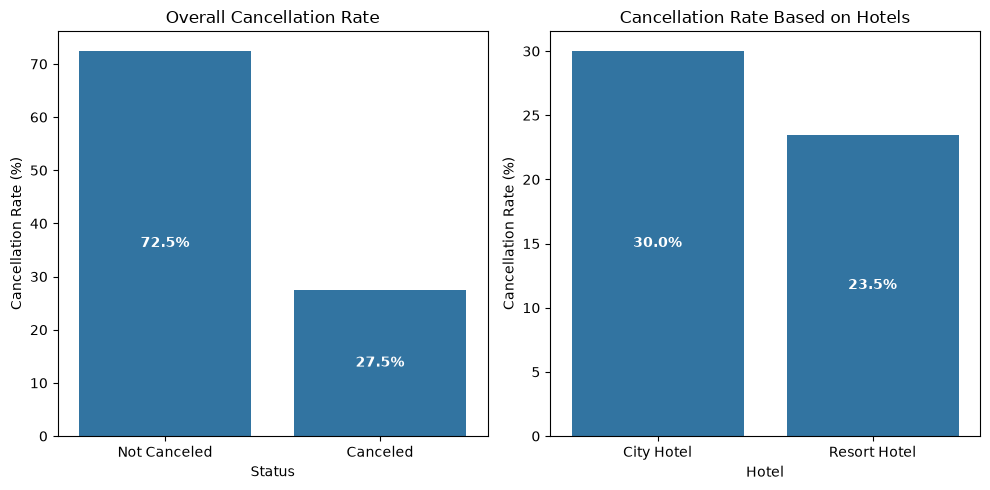

In [12]:
fig, ax = plt.subplots(figsize=(10,5), nrows=1, ncols=2)

by_hotel = pd.DataFrame(df.groupby("hotel")["is_canceled"].mean().mul(100)).reset_index()
by_hotel.columns = ["hotel", "rate"]

overall = pd.DataFrame(df["is_canceled"].value_counts(normalize=True).mul(100)).reset_index()
overall.columns = ["status", "rate"] 
overall["status"] = overall["status"].map({1:"Canceled", 0:"Not Canceled"})

sns.barplot(data=overall, x="status", y="rate", ax=ax[0])
ax[0].set_title("Overall Cancellation Rate")
ax[0].set_xlabel("Status")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white", fontweight="bold")


sns.barplot(data=by_hotel, x="hotel", y="rate", ax=ax[1])
ax[1].set_title("Cancellation Rate Based on Hotels")
ax[1].set_xlabel("Hotel")
ax[1].set_ylabel("Cancellation Rate (%)")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

The overall cancellation rate sits at about 27.5%, so roughly 3 out of every 10 bookings in this dataset never actually happen. That's enough to make forecasting and inventory planning genuinely hard for a hotel, since almost 30% of "confirmed" rooms might end up empty again.

Splitting by hotel type tells a more interesting story though. City Hotel bookings get canceled about 30% of the time, while Resort Hotel bookings sit lower, around 23.5%. That's almost a 7-point gap.

A few things could explain this. Maybe resort guests are booking family vacations planned well in advance and harder to change, while city hotel guests are more often business travelers or short-trip tourists whose plans shift more easily. It could also come down to money - resort stays might carry stricter deposit or non-refundable terms that make canceling more costly. Or it might just be about how far ahead people book at each hotel type. Worth digging into over the next few questions.


## 2. Does party size change the cancellation rate?

In [13]:
df["population"] = df["children"] + df["babies"] + df["adults"]
df["party_size"] = np.where((df["population"] > 2), "Family/Group(3+ Guests)" ,"Single/Couple(1-2 Guests)")
df["party_size"] = df["party_size"].astype("category")

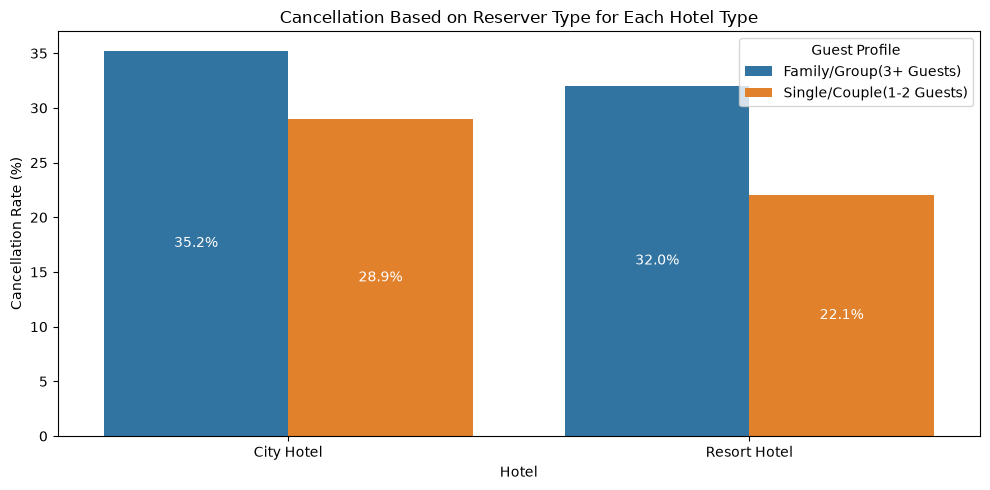

In [14]:
by_party_size = pd.DataFrame(df.groupby(["hotel","party_size"])["is_canceled"].mean().mul(100).reset_index())
by_party_size.columns = ["hotel","party_label","cancel_rate"]

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=by_party_size, x="hotel", y="cancel_rate", hue="party_label", ax=ax)
ax.set_title("Cancellation Based on Reserver Type for Each Hotel Type")
ax.set_xlabel("Hotel")
ax.set_ylabel("Cancellation Rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", color="white")
ax.legend(title="Guest Profile")

plt.tight_layout()
plt.show()

### Observation

Splitting guests into Solo/Couple (1-2 people) and Family/Group (3+ people), party size actually does make a difference — and it's the opposite direction I expected. Groups cancel more than solo/couple bookings, not less, in both hotel types.

At City Hotel it's 35.2% for groups vs. 28.9% for solo/couples, a gap of about 6 points. At Resort Hotel it's 32.0% vs. 22.1%, a gap of 10 points — so the effect of party size is actually bigger at the Resort than at the City Hotel.

Hotel type still matters more overall — Resort Hotel cancels less than City Hotel in both guest categories — but the assumption that bigger groups are more "locked in" and less likely to cancel doesn't hold up. If anything, more people on a booking probably means more chances for someone's plans to fall through, which drags the whole reservation down with it.

## 3. Does traveling with kids affect the cancellation rate?

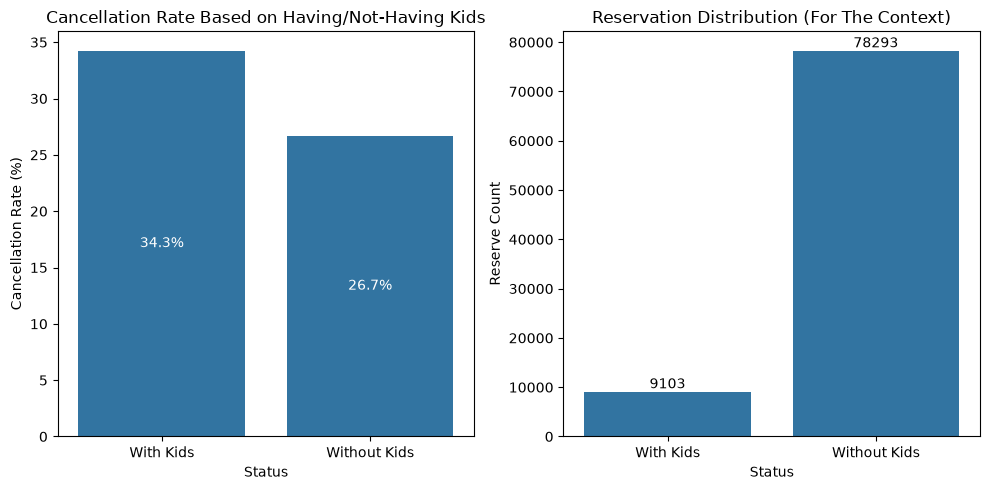

In [15]:
df["has_kids"] = np.where((df["children"]>0) | (df["babies"]>0), "With Kids", "Without Kids")
by_kids = df.groupby(["has_kids"])["is_canceled"].mean().mul(100).sort_index().reset_index()
by_kids.columns = ["has_kids", "cancel_rate"]

fig, ax = plt.subplots(figsize=(10,5), nrows=1, ncols=2)
sns.barplot(data=by_kids, x="has_kids", y="cancel_rate", ax=ax[0])
ax[0].set_title("Cancellation Rate Based on Having/Not-Having Kids")
ax[0].set_xlabel("Status")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

by_kids_count = df["has_kids"].value_counts().sort_index().reset_index()

sns.barplot(data=by_kids_count, x="has_kids", y="count", ax=ax[1])
ax[1].set_title("Reservation Distribution (For The Context)")
ax[1].set_xlabel("Status")
ax[1].set_ylabel("Reserve Count")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

plt.tight_layout()
plt.show()

### Observation

Bookings with kids cancel more often than bookings without: 34.3% vs. 26.7%, a gap of about 7.6 points — similar in size to the hotel-type effect I found earlier, so this isn't something to write off as noise.

One thing worth flagging though: bookings with kids are a small slice of the data — only 9,103 out of roughly 87,000 total, compared to 78,293 without kids. That doesn't invalidate the pattern, but it's worth keeping in mind that this reading comes from a much smaller group. It could be worth revisiting this split by hotel type too, since the "with kids" bookings might be concentrated more heavily at one hotel type, which could be part of what's driving the gap rather than kids themselves.

#### 4. Is lead time linked to cancellation?

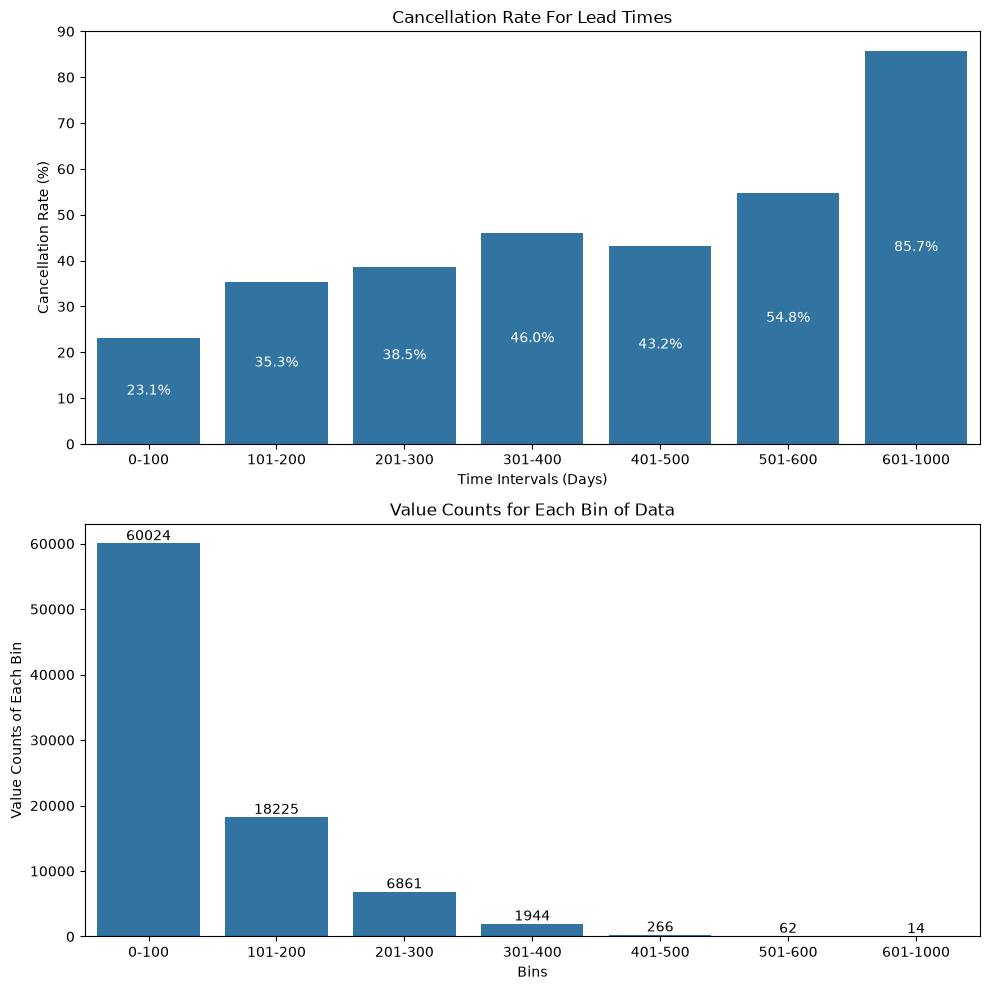

In [16]:
df["lead_time_chunks"] = pd.cut(df["lead_time"], bins=[-1,100,200,300,400,500,600,1000],
                          labels=["0-100","101-200","201-300","301-400","401-500","501-600","601-1000"])
by_lead = df.groupby(["lead_time_chunks"])["is_canceled"].mean().mul(100).reset_index()
by_lead.columns = ["times", "rate"]

by_lead_count = df["lead_time_chunks"].value_counts().sort_index().reset_index()
by_lead_count.columns = ["bins", "value_counts"]

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)

sns.barplot(data=by_lead, x="times", y="rate", ax=ax[0])
ax[0].set_title("Cancellation Rate For Lead Times")
ax[0].set_xlabel("Time Intervals (Days)")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

sns.barplot(data=by_lead_count, x="bins", y="value_counts", ax=ax[1])
ax[1].set_title("Value Counts for Each Bin of Data")
ax[1].set_xlabel("Bins")
ax[1].set_ylabel("Value Counts of Each Bin")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

plt.tight_layout()
plt.show()

### Observation

Cancellation rate climbs fairly steadily with lead time: 23.1% for bookings made within 100 days, rising to 35.3% (101-200 days), 38.5% (201-300 days), and 46.0% (301-400 days). It dips slightly to 43.2% for 401-500 days before climbing again to 54.8% (501-600 days) and 85.7% for 600+ days.

Sample size drops off fast though — the 0-100 day bin alone has 60,024 bookings, while everything past 300 days combined is under 2,300 bookings, and the last three bins (401-500, 501-600, 601-1000) have only 266, 62, and 14 bookings respectively. So the overall upward trend from short to long lead times is solid, but the exact percentages past 300 days — especially that 85.7% — are based on very few bookings and shouldn't be treated as a precise, reliable number.

## 5. Does length of stay matter?

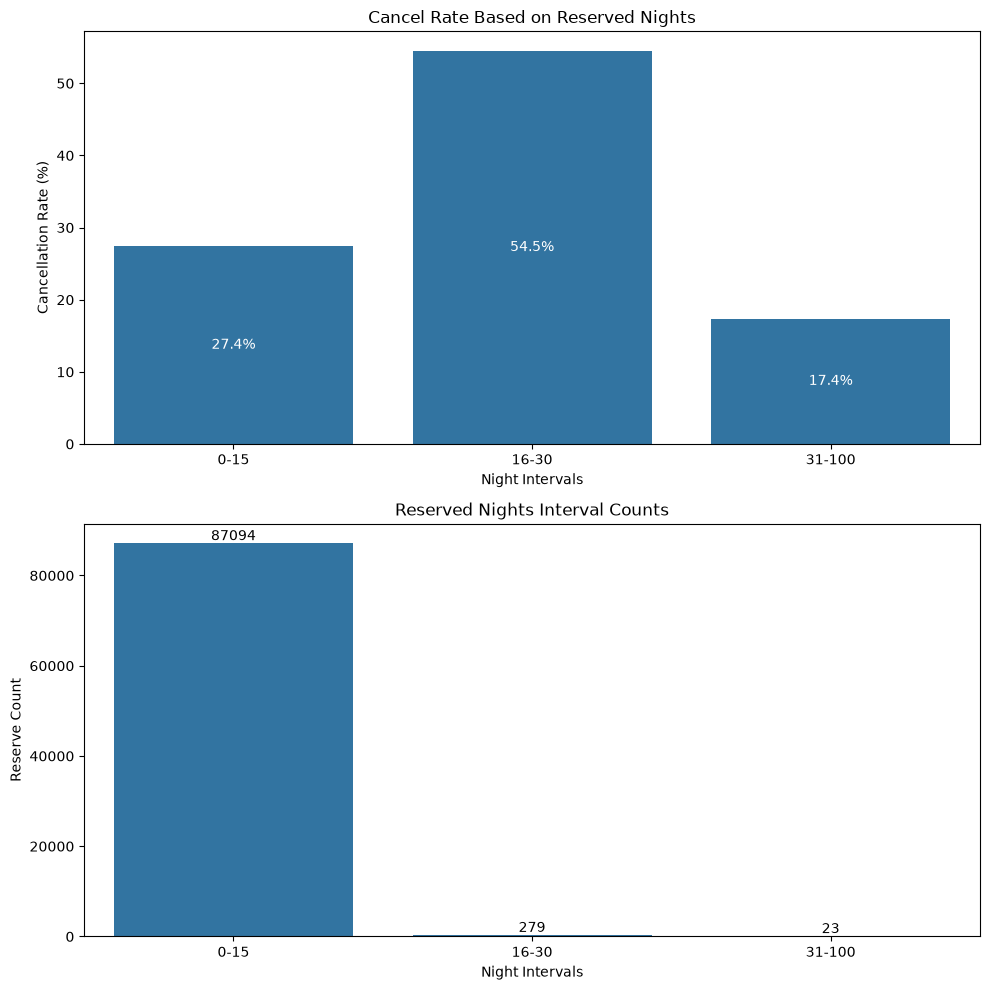

In [17]:
df["stay_nights"] = pd.cut(df["stay_nights"],
                     bins=[-1,15,30,100],
                    labels=["0-15","16-30","31-100"])

by_staying = df.groupby(["stay_nights"])["is_canceled"].mean().mul(100).reset_index()
by_staying.columns = ["nights", "cancel_rate"]

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)
sns.barplot(data=by_staying, x="nights", y="cancel_rate", ax=ax[0])
ax[0].set_title("Cancel Rate Based on Reserved Nights")
ax[0].set_xlabel("Night Intervals")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

by_staying_count = df["stay_nights"].value_counts().sort_index().reset_index()
by_staying_count.columns = ["nights", "count"]

sns.barplot(data=by_staying_count, x="nights", y="count", ax=ax[1])
ax[1].set_title("Reserved Nights Interval Counts")
ax[1].set_xlabel("Night Intervals")
ax[1].set_ylabel("Reserve Count")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

plt.tight_layout()
plt.show()

### Observation

Stays of 0-15 nights cancel at 27.4%, close to the overall baseline. That rate roughly doubles to 54.5% for stays of 16-30 nights, then drops sharply to 17.4% for 31-100 nights — the lowest of the three groups.

That last number is worth treating carefully though: the 0-15 night bucket covers 87,094 bookings, while 16-30 nights has only 279 and 31-100 nights has just 23. So the 16-30 and 31-100 night rates are each based on a tiny slice of the data, and the drop to 17.4% for the longest stays could easily be a handful of specific bookings rather than a real pattern. The only interval with enough data to trust is 0-15 nights.

## 6. Are new guests more likely to cancel than returning guests?

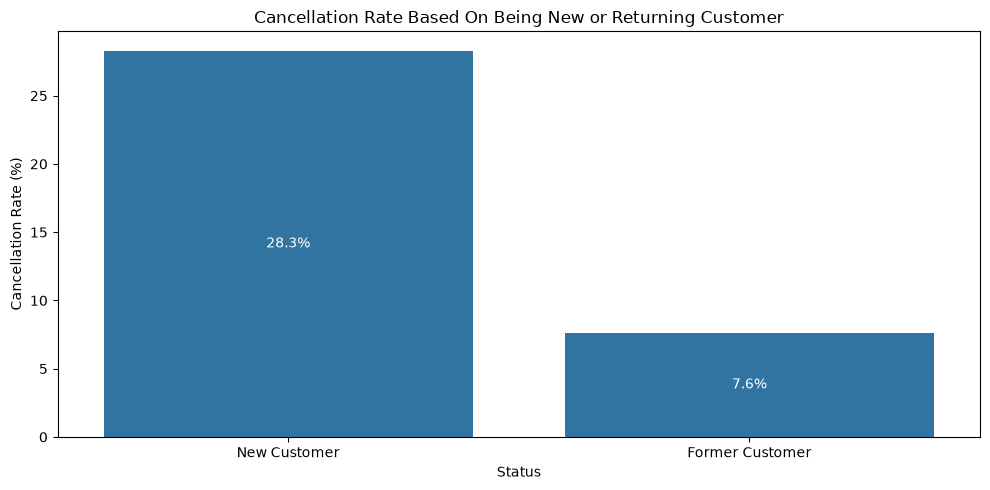

In [18]:
by_guest = df.groupby(["is_repeated_guest"])["is_canceled"].mean().mul(100).reset_index()
by_guest.columns = ["guest_status", "rate"]
by_guest["guest_status"] = by_guest["guest_status"].map({0:"New Customer", 1:"Former Customer"})
df["guest_type"] = np.where(df["is_repeated_guest"] == 1,"Former Customer", "New Customer")

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=by_guest, x="guest_status", y="rate", ax=ax)
ax.set_title("Cancellation Rate Based On Being New or Returning Customer")
ax.set_xlabel("Status")
ax.set_ylabel("Cancellation Rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", color="white")

plt.tight_layout()
plt.show()

### Observation

Former customers cancel far less often than new customers — 7.6% vs. 28.3%, a gap of about 20.7 points. That's one of the biggest differences in the whole notebook so far, much larger than the gap seen for hotel type, party size, or kids.

## 7. Do people with a history of canceling keep canceling?

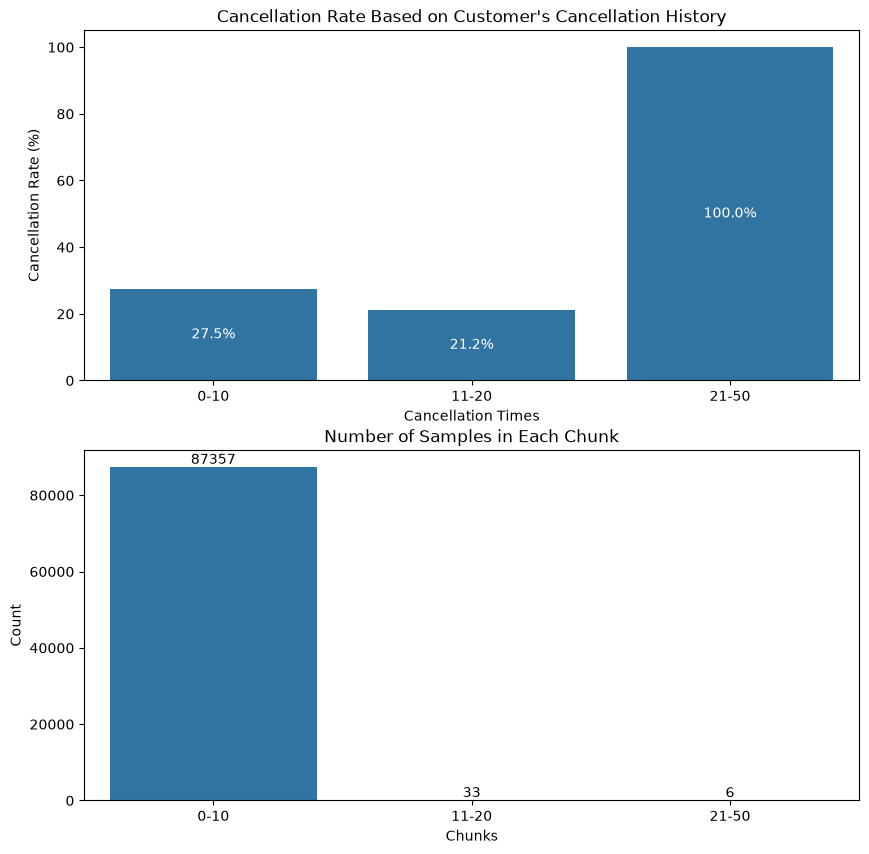

In [19]:
df["cancellation_chunks"] = pd.cut(df["previous_cancellations"], bins=[-1,10,20,50], labels=["0-10","11-20","21-50"])
by_cancellation = df.groupby(["cancellation_chunks"])["is_canceled"].mean().mul(100).reset_index()
by_cancellation.columns = ["cancel_count", "rate"]

by_cancellation_count = df["cancellation_chunks"].value_counts().sort_index().reset_index()

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)
sns.barplot(data=by_cancellation, x="cancel_count", y="rate", ax=ax[0])
ax[0].set_title("Cancellation Rate Based on Customer's Cancellation History")
ax[0].set_xlabel("Cancellation Times")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

sns.barplot(data=by_cancellation_count, x="cancellation_chunks", y="count", ax=ax[1])
ax[1].set_title("Number of Samples in Each Chunk")
ax[1].set_xlabel("Chunks")
ax[1].set_ylabel("Count")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

### Observation
Customers with 0-10 previous cancellations cancel at 27.5%, close to baseline. Customers with 11-20 previous cancellations cancel slightly less, at 21.2%, and those with 21-50 previous cancellations cancel 100% of the time.

That last two numbers need a big caveat though: the 0-10 bucket has 87,357 customers, but the 11-20 bucket has only 33 and the 21-50 bucket has just 6. So the "100% cancellation" result comes from 6 bookings total — not a reliable signal, just what happened to those six. Same goes for the 21.2% in the middle bucket. The only trustworthy number here is the 0-10 group; the other two are too small to draw real conclusions from.

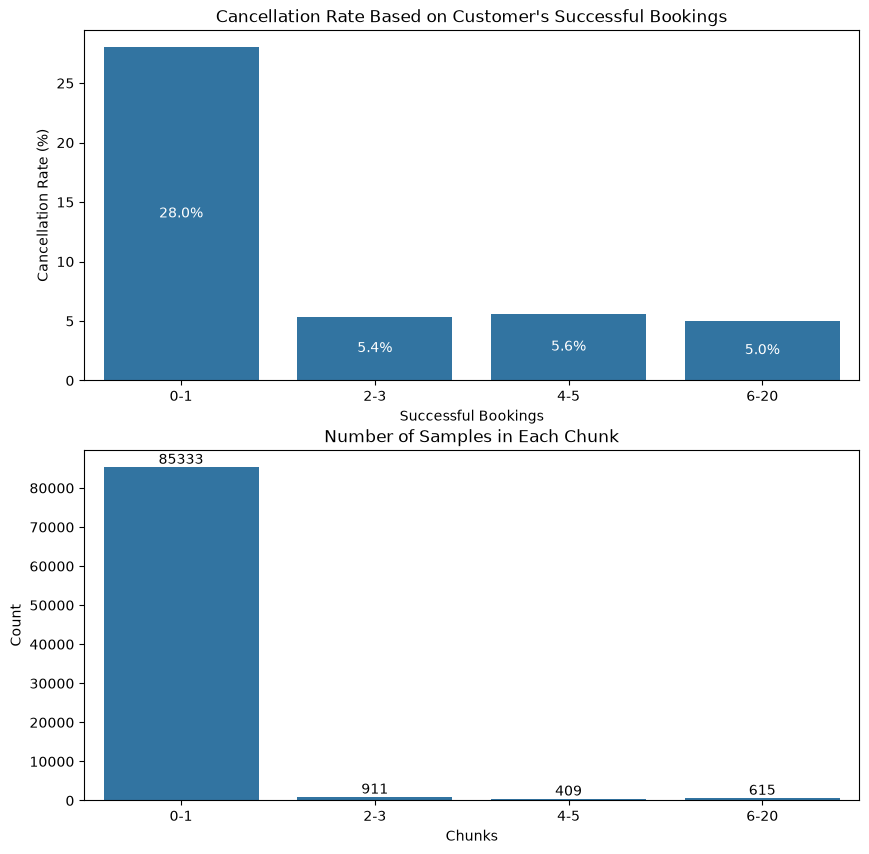

In [20]:
df["not_canceled_chunks"] = pd.cut(df["previous_bookings_not_canceled"], bins=[-1,1,3,5,20], labels=["0-1","2-3","4-5","6-20"])
by_notcancellation = df.groupby(["not_canceled_chunks"])["is_canceled"].mean().mul(100).reset_index()
by_notcancellation.columns = ["value_chunks", "rate"]

by_notcancellation_count = df["not_canceled_chunks"].value_counts().sort_index().reset_index()
by_notcancellation_count.columns = ["value_chunks", "count"]

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)
sns.barplot(data=by_notcancellation, x="value_chunks", y="rate", ax=ax[0])
ax[0].set_title("Cancellation Rate Based on Customer's Successful Bookings")
ax[0].set_xlabel("Successful Bookings")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

sns.barplot(data=by_notcancellation_count, x="value_chunks", y="count", ax=ax[1])
ax[1].set_title("Number of Samples in Each Chunk")
ax[1].set_xlabel("Chunks")
ax[1].set_ylabel("Count")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

### Observation
Customers with 0-1 previous non-canceled bookings cancel at 28.0%, close to baseline. Once someone has 2 or more successful bookings, cancellation drops sharply and stays there — 5.4% for 2-3, 5.6% for 4-5, and 5.0% for 6-20. So the drop happens right after the first successful stay and doesn't change much after that.

Sample sizes are more reasonable here than in some earlier charts — 911, 409, and 615 bookings in the three higher groups — so this pattern is on firmer ground than the previous cancellation-history chart, even though the 0-1 group (85,333) still dominates. The takeaway: one successful stay is basically the turning point where a customer goes from baseline risk to a consistent ~5% cancellation rate.

## 8. Does time spent on the waiting list affect cancellation?

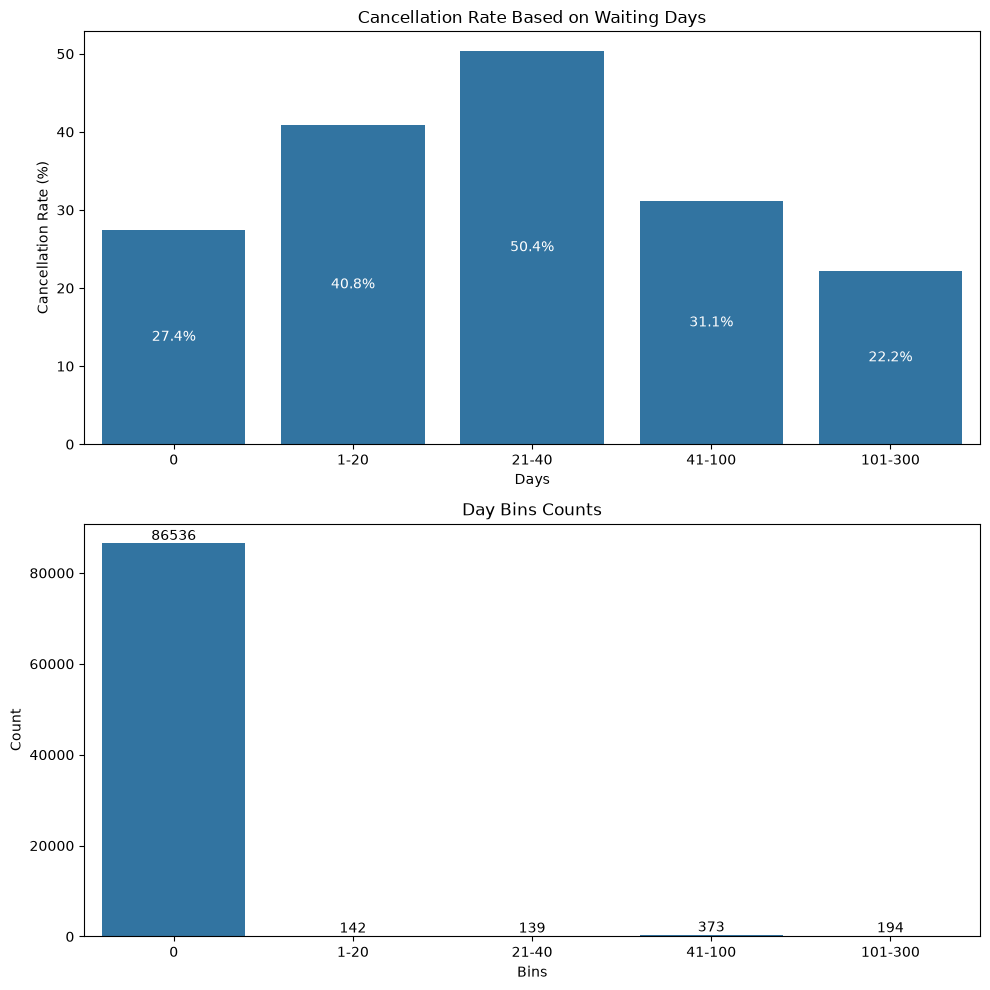

In [21]:
df["waiting_days_chunks"] = pd.cut(df["days_in_waiting_list"],
                                   bins=[-1,0,20,40,100,300],
                                   labels=["0","1-20","21-40","41-100","101-300"])

by_waiting = df.groupby(["waiting_days_chunks"])["is_canceled"].mean().mul(100).reset_index()
by_waiting.columns = ["day_chunks", "rate"]

waiting_bins = df["waiting_days_chunks"].value_counts().sort_index().reset_index()

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)

sns.barplot(data=by_waiting, x="day_chunks", y="rate", ax=ax[0])
ax[0].set_title("Cancellation Rate Based on Waiting Days")
ax[0].set_xlabel("Days")
ax[0].set_ylabel("Cancellation Rate (%)")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

sns.barplot(data=waiting_bins, x="waiting_days_chunks", y="count", ax=ax[1])
ax[1].set_title("Day Bins Counts")
ax[1].set_xlabel("Bins")
ax[1].set_ylabel("Count")
for container in ax[1].containers:
    ax[1].bar_label(container, label_type="edge", color="black")

plt.tight_layout()
plt.show()

### Observation
Bookings with no wait at all cancel at 27.4%, close to baseline. Once a booking has to wait, cancellation jumps — 40.8% for 1-20 days, peaking at 50.4% for 21-40 days — then drops back down to 31.1% for 41-100 days and 22.2% for 101-300 days, ending up lower than the no-wait group.

So the risk isn't a straight line — it rises sharply, peaks around the 21-40 day mark, then falls again for longer waits. Worth keeping in mind that the "0 days" group has 86,536 bookings, while every other bucket is small (139-373 bookings), so the shape of the curve (rise then fall) is suggestive but each individual percentage past day 0 is based on a fairly thin slice of data.

### Conclusion

Looking back across all eight questions, a few things stand out more than others.

Guest history is probably the biggest one. The gap between new and returning guests (28.3% vs 7.6%) is the largest single difference I found anywhere in this analysis, and it lines up with the previous-successful-booking pattern too — once someone has one completed stay under their belt, their cancellation rate drops to around 5% and just stays there. If I had to pick one thing a hotel should pay attention to, it's this.

Hotel type shows up as a consistent factor too, not just on its own but underneath the other splits — Resort Hotel comes in lower than City Hotel pretty much everywhere I looked, including once party size gets factored in.

Lead time was one of the more surprising ones, mostly because it held up so well — cancellation rate climbs steadily the further out someone books, from about 23% within 100 days up past 50% for the longest lead times. The trend itself feels real even if I wouldn't trust the exact number at the very top of the range, since there's only a handful of bookings out there.

Party size and kids both went the opposite way from what I expected going in. I assumed bigger groups and families would be more committed to their trip and less likely to bail, but it's the reverse — more people on a booking seems to mean more chances for someone's plans to fall apart, which drags the whole reservation down with it.

A handful of the other splits (previous cancellation count, waiting list days, length of stay) had some pretty dramatic-looking numbers, but I don't fully trust them. Most of those come from buckets with a few dozen bookings or fewer, sometimes less than ten, so a couple of unusual cases can swing the percentage a lot. The "100% cancellation" result from the previous-cancellations chart is a good example — that's 6 bookings, not a real trend.

So if I had to boil it down: guest history and hotel type are the two most reliable levers here, lead time is a solid trend worth building into any policy thinking, and party size/kids matter more than expected but probably need to be untangled from each other since families likely show up in both groups at once. Everything from the smaller buckets is worth revisiting with more data before treating it as fact.